In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import numpy.linalg as LA
import scipy.constants as const
from scipy.spatial.transform import Rotation

import matplotlib.pyplot as plt
%matplotlib ipympl


import sys
sys.path.append('E:/google-drive/py_projects/satellites/src')
# import satellites as sat
import stateest as se
import utils

In [2]:
rng = np.random.default_rng(seed=4211)

In [3]:
se.gen_newtonian_motion_update_matrix(0.01, 2)

array([[0.e+00, 1.e-02, 5.e-05],
       [0.e+00, 0.e+00, 1.e-02],
       [0.e+00, 0.e+00, 0.e+00]])


# Example: tracking 1D position with constant velocity

## Simulate some noisy measurements

In [125]:
time_step = 0.5
n_measurements = 120
timevec = np.arange(n_measurements) * time_step
xtrue_init = 10
vtrue = 10
vmeas = vtrue + rng.normal(0, 2, n_measurements)
xtrue = np.cumsum(time_step*vmeas) + xtrue_init 
xmeas = xtrue + rng.normal(0, 1, n_measurements)

measurements = xmeas
# measurements = np.vstack((xmeas, vmeas)).T


## Kalman Filter 

True position: ['15.93', '20.88', '25.23', '30.96', '36.68', '43.76', '49.99', '56.00', '59.98', '64.32', '69.65', '75.93', '79.50', '84.42', '89.37', '95.45', '100.26', '105.82', '112.85', '118.28', '121.34', '126.31', '131.37', '137.24', '142.60', '148.40', '152.39', '158.12', '163.04', '168.96', '173.20', '178.70', '184.82', '190.25', '196.04', '203.05', '206.63', '212.01', '220.14', '225.22', '228.79', '233.04', '238.86', '244.99', '248.84', '253.15', '258.30', '263.41', '267.96', '273.73', '279.78', '285.10', '290.04', '293.24', '298.46', '303.03', '308.37', '311.48', '317.72', '322.67', '327.70', '333.77', '337.27', '342.37', '346.31', '351.61', '354.91', '359.86', '364.75', '369.69', '374.59', '377.60', '382.75', '387.42', '392.02', '396.00', '401.31', '405.94', '408.97', '413.03', '418.24', '422.52', '426.83', '430.82', '436.91', '441.87', '448.03', '454.53', '459.40', '463.61', '467.04', '472.00', '477.48', '482.17', '487.94', '492.47', '498.42', '501.94', '508.17', '512.14', 

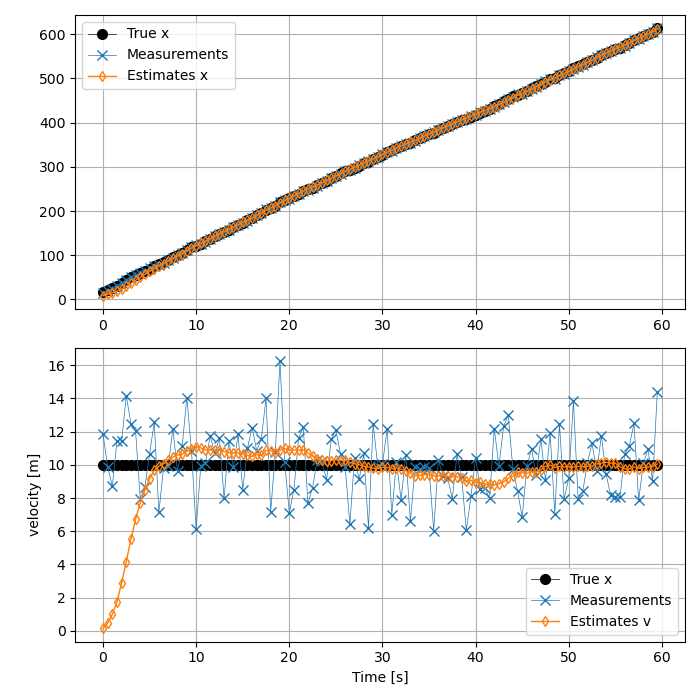

In [126]:

dt = time_step
# state: [position, velocity]       
F = se.gen_newtonian_motion_update_matrix(dt, state_vec_order=1)
# measurement process (state to measurement)
H = np.array([[1,0]])
# H = np.array([
#     [1, 0],
#     [0, 1]
#     ])
# process noise
Q = np.array([
    [1, 0],
    [0, 1]
    ]) *1
# measurement noise
R = np.array([[201]])
# R = np.array([
#     [0.1, 0],
#     [0, 0.1]
#     ]) 

# initial state
x0 = np.array([[5, 0]]).T
# initial uncertainty. make high to convey broader prior
P0 = np.array([
    [100, 0],
    [0, 9],
])         
# controls
B = np.eye(2)
u = np.zeros_like(x0)

# init Kalman filter
kf = se.KalmanFilter(x0, P0, F, B, u, Q, H, R )

for z in measurements:
    x_est, _ = kf.perform_epoch(u=None, z=z.reshape([-1,1]), postcovkwargs={'stable':True})


print("True position:", [f"{e:.2f}" for e in xtrue])
print("Measured:", [f"{e:.2f}" for e in xmeas])
# estimatesxv = np.reshape(kf.x,[-1,2])[2::2, :]
estimatesxv = kf.get_states(which='estimates')
print("Estimates:", [f"{e:.2f}" for e in estimatesxv[:,0]])
kfstates = kf.get_states(which='all')

fig, axs = plt.subplots(2,1, figsize=[7,7])
axs[0].plot(timevec, xtrue, lw=0.5, marker='o', ms=7, color='k', label='True x')
axs[0].plot(timevec, xmeas, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
axs[0].plot(timevec, estimatesxv[:,0], lw=1, marker='d', ms=5, color='tab:orange', mfc='none',label='Estimates x')
# axs[0].plot( dt*(0.5*np.arange(kfstates.shape[0]) - 1) , kfstates[:,0], lw=1, marker='x', ms=5, color='tab:orange', label='all states')
axs[0].legend()

axs[1].plot(timevec, vtrue*np.ones(n_measurements), lw=0.5, marker='o', ms=7, color='k', label='True x')
axs[1].plot(timevec, vmeas, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
axs[1].plot(timevec, estimatesxv[:,1], lw=1, marker='d', ms=5, color='tab:orange',mfc='none', label='Estimates v')
# axs[1].plot( dt*(0.5*np.arange(kfstates.shape[0]) - 1) , kfstates[:,1], lw=1, marker='x', ms=5, color='tab:orange', label='all states')

axs[1].legend()

axkwargs = {
    # 'xticks': timevec[::10],
    # 'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'velocity [m]',
}
axs[1].set(**axkwargs)
for ax in axs:
    ax.grid(True)
    
plt.tight_layout()
plt.show()

In [106]:
plt.close('all')

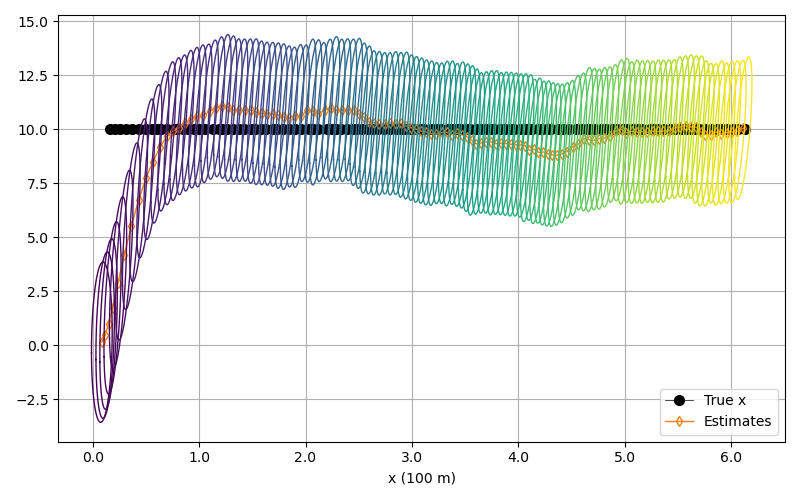

In [127]:

colors = plt.cm.viridis(np.linspace(0, 1, n_measurements))

fig, ax = plt.subplots(1,1, figsize=[8,5], squeeze=True)
ax.plot(xtrue, vtrue*np.ones_like(xtrue), lw=0.5, marker='o', ms=7, color='k', label='True x')
# ax.plot( measurements[:,0], measurements[:,1], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
ax.plot( estimatesxv[:,0], estimatesxv[:,1], lw=1, marker='d', ms=5, color='tab:orange', mfc='none', label='Estimates')

estimates_cov = kf.get_covariances(which='estimates')
for i, (xv, cov) in enumerate(zip(estimatesxv, estimates_cov)):
    xy = utils.generate_covariance_ellipse(xv, cov, enclosed_frac=0.5)
    ax.plot(xy[0], xy[1], lw=1, color=colors[i])
    # ax.plot(xv[0], xv[1], c=colors[i])
ax.legend()
# ax.plot(timevec, measurements[:,0] - true_positions, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurement - Truth')
# ax.plot(timevec, estimates - true_positions, lw=1, marker='x', ms=5, color='tab:red', label='Estimate - Truth')
# ax.legend()

axkwargs = {
    # 'xticks': timevec[::10],
    # 'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'Position difference from truth [m]',
    'aspect': 'equal',
}
# axs[1].set(**axkwargs)
from matplotlib.ticker import FuncFormatter

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: x / 100))
ax.set_xlabel('x (100 m)')

ax.grid(True)
plt.tight_layout()
plt.show()

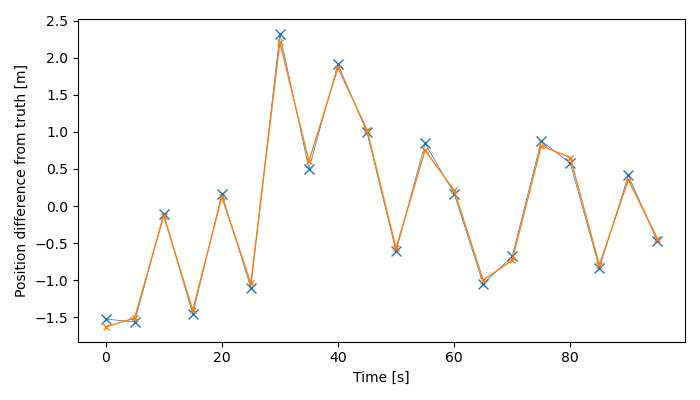

In [78]:
fig, ax = plt.subplots(1,1, figsize=[7,4])

ax.plot(timevec, xmeas - xtrue, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurement - Truth')
ax.plot(timevec, estimatesxv[:,0] - xtrue, lw=1, marker='x', ms=5, color='tab:orange', label='Estimatex - Truth')

axkwargs = {
    # 'xticks': timevec,
    # 'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'Position difference from truth [m]',
}
ax.set(**axkwargs)
plt.tight_layout()
plt.show()

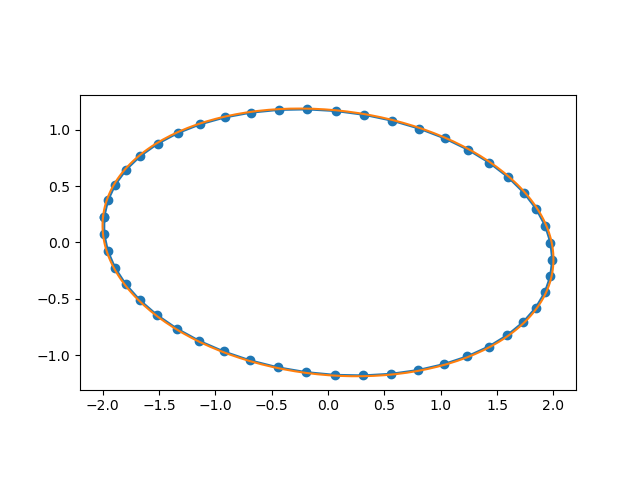

In [ ]:
A = np.array([
    [4, -0.3],
    [-0.3, 1.41],
])
xyc = np.array([0,0])
xy = utils.generate_covariance_ellipse(xyc, A, enclosed_frac=0.39)
v1,v2 = utils.covariance_ellipse_vectors(A)
xy_old = utils.generate_ellipse_xy(xyc, v1, v2, npts=250)
fig, ax = plt.subplots()
ax.plot(xy[0], xy[1], marker='o' )
ax.plot(xy_old[0], xy_old[1], )
ax.set_aspect('equal')

plt.show()

In [24]:
plt.close('all')

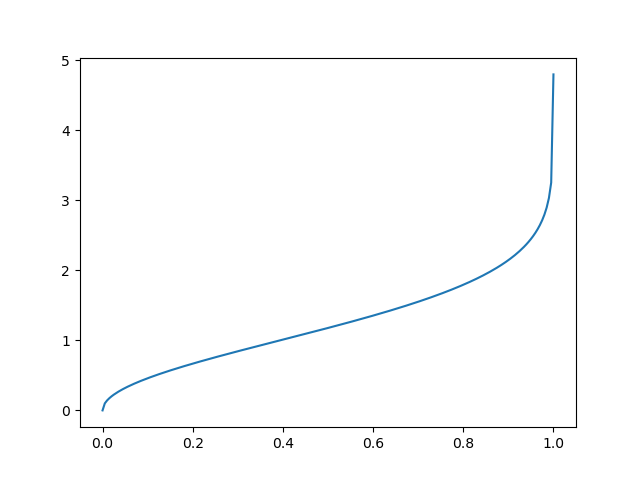

In [61]:
a = np.linspace(0,1-1e-5,200)
r2 = np.sqrt(-2*np.log(1 - a))
fig, ax = plt.subplots()
ax.plot(a, r2)


In [60]:
(1 - 1/np.e/2)

0.8160602794142788

# Example: constant acceleration

Estimates: ['52.51', '53.83', '54.13', '54.13', '54.57', '54.71', '55.11', '55.21', '55.82', '56.08', '56.29', '56.36', '56.48', '57.31', '57.63', '58.11', '58.44', '58.85', '59.74', '61.04', '62.22', '63.52', '65.02', '66.89', '68.73', '70.20', '72.04', '74.08', '76.69', '78.96', '81.30', '84.37', '87.45', '90.62', '93.94', '97.84', '101.59', '105.46', '109.72', '113.96', '118.85', '123.27', '128.76', '134.26', '140.21', '146.23', '152.42', '158.40', '165.56', '172.06', '178.74', '185.85', '193.70', '201.81', '209.83', '218.60', '227.42', '236.85', '246.09', '255.73', '265.11', '275.69', '286.28', '297.41', '308.32', '319.45', '330.52', '341.72', '353.72', '366.02', '379.33', '392.36', '405.13', '418.27', '432.23', '446.52', '461.04', '475.42', '490.34', '505.24', '520.75', '535.77', '551.65', '567.56', '583.57', '599.75', '616.60', '633.70', '650.27', '667.40', '684.73', '702.06', '720.36', '738.66', '756.77', '775.33', '794.02', '812.66', '831.40', '850.88']


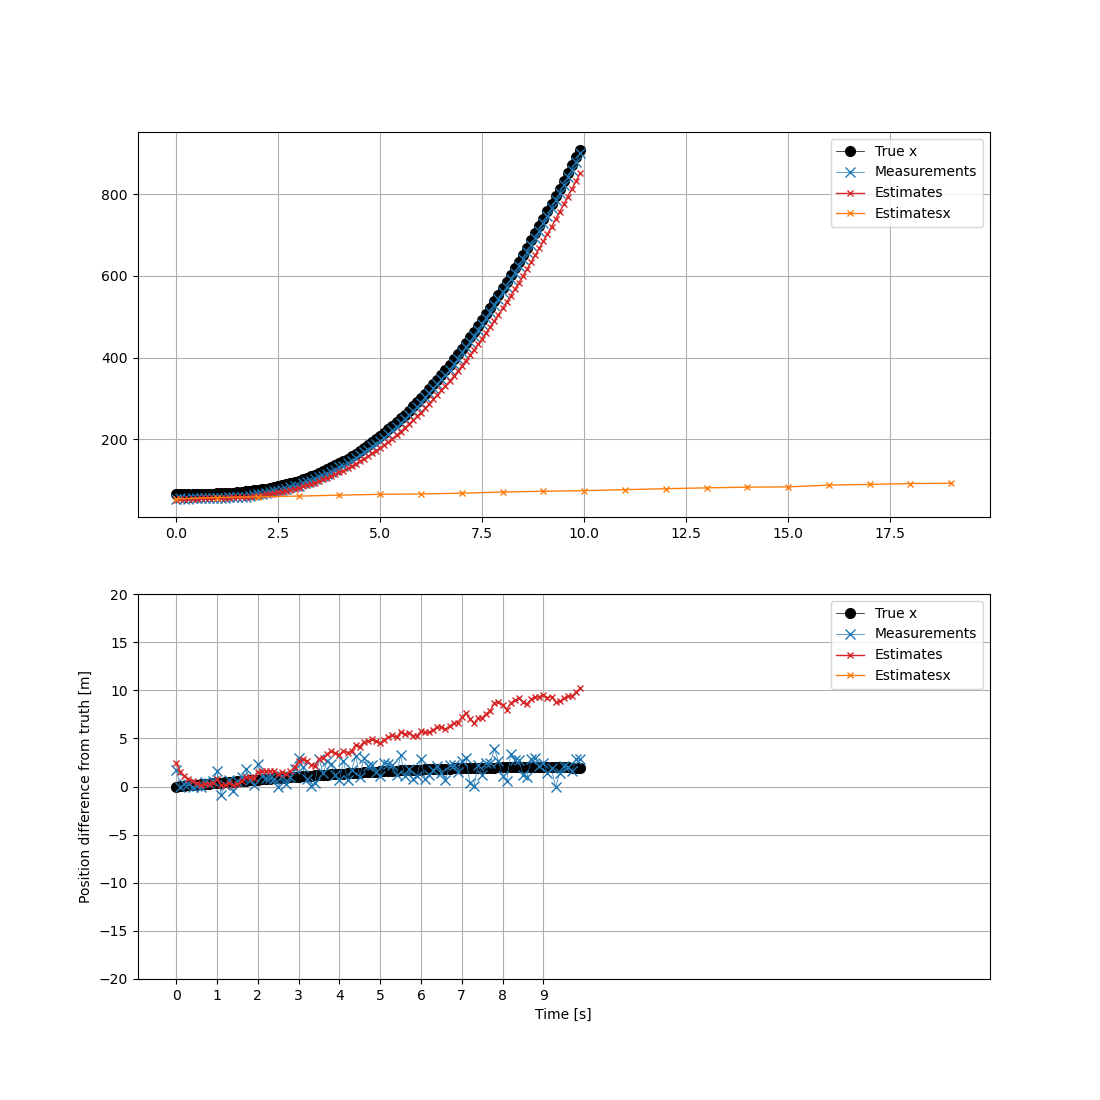

In [8]:

dt = 0.10

F = np.array([[1, dt, 0.5 * dt**2],
              [0, 1, dt],
              [0, 0, 1]])       # state: [position, velocity]

H = np.array([[1, 0, 0],
              [0, 1, 0]])       # measurement process

Q = np.array([[1, 0, 0],
              [0, 1, 0],
              [0, 0, 1]]) * 0.1 # process noise

R = np.array([[1.0, 0],
              [0, 1]]) # measurement noise

# initial state
x0 = np.array([[50],
               [3],
               [0]])
P0 = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1] ])         # high initial uncertainty
# controls
B = np.eye(2)
u = np.zeros_like(x0)

# init Kalman filter
kf = se.KalmanFilter(x0, P0, F, B, u, Q, H, R )

# Simulate some noisy measurements
timevec = np.arange(100) * dt
vtrue = 2 * np.sin(2*const.pi*timevec/35)
true_positions = np.cumsum(vtrue * timevec) + 66
xmeas = true_positions - 11 + rng.normal(0, 1, true_positions.shape) 
vmeas = rng.normal(vtrue, 1, true_positions.shape)
measurements = np.vstack((xmeas, vmeas)).T
estimates = []
estimatesv = []
for z in measurements:
    # kf.model_predition_step()
    # x_est, _ = kf.measurement_update_step(np.array([[z]]), {'stable':True})
    x_est, _ = kf.perform_epoch(u=None, z=z.reshape([-1,1]), postcovkwargs={'stable':True})
    estimates.append(x_est[0, 0])
    estimatesv.append(x_est[1, 0])

print("Estimates:", [f"{e:.2f}" for e in estimates])

estimatesxva = np.reshape(kf.x,[-1,3])


fig, axs = plt.subplots(2,1, figsize=[11,11])
axs[0].plot(timevec, true_positions, lw=0.5, marker='o', ms=7, color='k', label='True x')
axs[0].plot(timevec, measurements[:,0], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
axs[0].plot(timevec, estimates, lw=1, marker='x', ms=5, color='tab:red', label='Estimates')
axs[0].plot(estimatesxv[2::2,0], lw=1, marker='x', ms=5, color='tab:orange', label='Estimatesx')
axs[0].legend()
axs[1].plot(timevec, vtrue, lw=0.5, marker='o', ms=7, color='k', label='True x')
axs[1].plot(timevec, measurements[:,1], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
axs[1].plot(timevec, estimatesv, lw=1, marker='x', ms=5, color='tab:red', label='Estimates')
axs[1].plot(estimatesxv[2::2,0], lw=1, marker='x', ms=5, color='tab:orange', label='Estimatesx')
axs[1].legend()

axkwargs = {
    'xticks': timevec[::10],
    'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'Position difference from truth [m]',
}
axs[1].set(**axkwargs)
for ax in axs:
    ax.grid(True)
plt.show()

In [97]:
rng.normal(vtrue, 3).shape

(200,)

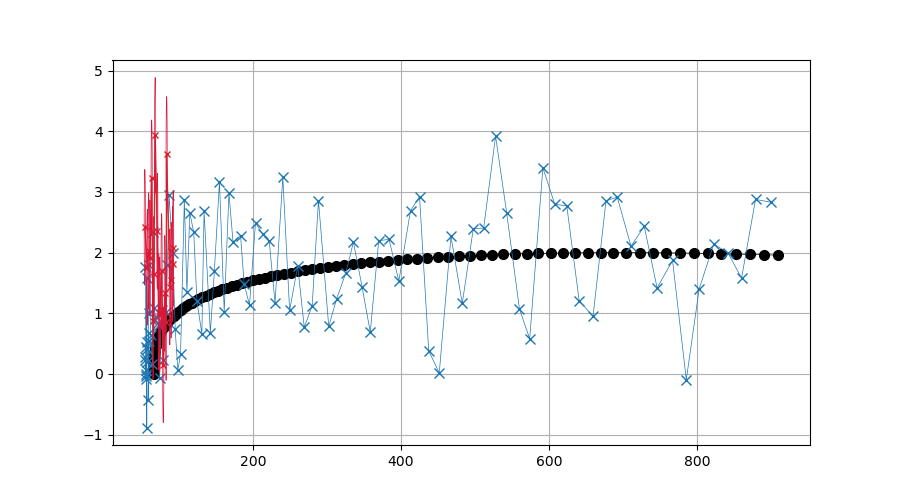

In [9]:


fig, ax = plt.subplots(1,1, figsize=[9,5], squeeze=True)
ax.plot(true_positions, vtrue*np.ones_like(true_positions), lw=0.5, marker='o', ms=7, color='k', label='True x')
ax.plot( measurements[:,0], measurements[:,1], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
ax.plot( estimatesxv[2::2,0], estimatesxv[2::2,1], lw=1, marker='x', ms=5, color='tab:red', label='Estimates')

for vs, est in zip(ellipse_vecs[2::2], estimatesxv[2::2]):
    xy = gen_ellipse(*vs) + est.reshape([-1,1])
    ax.plot(xy[0], xy[1], lw=0.5, color='crimson')
# ax.legend()
# ax.plot(timevec, measurements[:,0] - true_positions, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurement - Truth')
# ax.plot(timevec, estimates - true_positions, lw=1, marker='x', ms=5, color='tab:red', label='Estimate - Truth')
# ax.legend()

axkwargs = {
    'xticks': timevec[::10],
    'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'Position difference from truth [m]',
}
# axs[1].set(**axkwargs)
ax.grid(True)

plt.show()

# misc

In [13]:
a = np.ones(3)
print(a)
print(np.diag(a, k=1))

[1. 1. 1.]
[[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 0.]]


In [19]:
b = np.zeros([3,3])
idx = np.arange(2)
b[idx,idx+1] = 1
print(b)

[[0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 0.]]


In [20]:
c = np.diag(np.ones(3), k=1)

In [21]:
c

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 0.]])

In [25]:
c @ c @ c @ c

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [14]:
se.gen_newtonian_motion_update_matrix(0.5, state_vec_order=4, approx_order=11)

---
1
[[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]]
1
---
2
[[0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
2
---
3
[[0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
6
---
4
[[0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
24


array([[0.        , 0.5       , 0.125     , 0.02083333, 0.00260417],
       [0.        , 0.        , 0.5       , 0.125     , 0.02083333],
       [0.        , 0.        , 0.        , 0.5       , 0.125     ],
       [0.        , 0.        , 0.        , 0.        , 0.5       ],
       [0.        , 0.        , 0.        , 0.        , 0.        ]])